# 📌 Submission Guidelines

### ✅ File Naming Rule  
Submit your notebook with the following format:

`StudentID_YourFullName_LABXX.ipynb`

or

`StudentID_YourFullName_LABXX.html`

**Examples (Correct):**
- `21113456_NguyenVanA_LAB01.ipynb`
- `19122233_TranThiB_LAB02.ipynb`

**Examples (Wrong → 0 points):**
- `Lab01.ipynb`
- `YourName.ipynb`
- `20123456.ipynb`
- `Lab01.pdf`

---

### 📌 Grading Policy

- ❌ Wrong filename format, missing submission, or plagiarism (code identical to others) → 0 points

- ⚠️ Submitting a file without results, incomplete work, or only the assignment description → Maximum 4 points

- ✅ Correct filename + Completed results → Graded normally based on assignment quality (accuracy, clarity, and originality)  
### Note:
- AI assistance is allowed, but you must write the code yourself. All submissions will be checked for originality.

---



# LEARNING OBJECTIVES

After this lab session, students will be able to:

🎯 Understand:



*   What Bag of Words is
*   N-grams (unigram, bigram, trigram)
*   Term Frequency (TF)
*   Inverse Document Frequency (IDF)
*   The intuition behind TF-IDF
*   Why TF-IDF often performs better than raw counts in many cases


💻 Implement:


*   Vietnamese text preprocessing
*   Feature vector construction using:
    *   Bag of Words
    *   N-grams
    *   TF-IDF
*   Train a sentiment classification model
*   Compare the performance of different text representations






















#SHORT THEORY (Concise – Intuition-Based)

---

## 📦 Bag of Words (BoW)

> 💡 **Idea:**  
> Treat a document as a *bag of words* and ignore word order.

**Example**

"Tôi thích môn học này"

$\rightarrow$ [tôi: 1, thích: 1, môn: 1, học: 1, này: 1]


> ⚠️ Word order is **not considered**.

---

## 🔗 N-gram

An **N-gram** is a sequence of **N consecutive words**.

| Type | Example |
|------|---------|
| Unigram (1-gram) | tôi |
| Bigram (2-gram) | tôi thích |
| Trigram (3-gram) | tôi thích môn |


> ✅ **Why use N-grams?**
>
> - Capture local context  
> - Distinguish: **"không tốt" ≠ "tốt"**

---

##📊 Term Frequency (TF)

The frequency of a term in a document:

$$
TF(t, d) = \frac{f(t, d)}{|d|}
$$

Where:

- $f(t, d)$: number of times term $t$ appears in document $d$  
- $|d|$: total number of terms in $d$

> 💡 Measures how **important a word is within a document**.

---

##🌍 Inverse Document Frequency (IDF)

Reduces the weight of very common terms:

$$
IDF(t) = \log \frac{N}{df(t)}
$$

Where:

- $N$: total number of documents  
- $df(t)$: number of documents containing term $t$

> 📉 If a term appears in many documents → **low IDF**

---

##⚖️ TF–IDF

$$
TF\text{-}IDF(t, d) = TF(t, d) \times IDF(t)
$$

> 💡 **Intuition**
>
> A term is important if:
>
> - It appears **frequently in one document**
> - But is **rare in the whole corpus**
>
> → Highly representative for that document.

---

##🚀 Why is TF–IDF better than Raw Count?

🔴 **Raw Count**

- Common words like: *“là”, “và”, “của”* get high weights.

🟢 **TF–IDF**

- Down-weights uninformative frequent words  
- Emphasizes sentiment-bearing terms:

  - **“tệ”**
  - **“rất hay”**
  - **“khó hiểu”**

> ✅ Better for **text classification & sentiment analysis**

---


# Dataset
## Download INTRODUCTION
Vietnamese Students' Feedback Corpus (UIT-VSFC) is the resource consists of over 16,000 sentences which are human-annotated with two different tasks: sentiment-based and topic-based classifications.

DOI: [10.1109/KSE.2018.8573337](https://ieeexplore.ieee.org/document/8573337)

[1] Kiet Van Nguyen, Vu Duc Nguyen, Phu Xuan-Vinh Nguyen, Tham Thi-Hong Truong, Ngan Luu-Thuy Nguyen, UIT-VSFC: Vietnamese Students' Feedback Corpus for Sentiment Analysis,  2018 10th International Conference on Knowledge and Systems Engineering (KSE 2018), November 1-3, 2018, Ho Chi Minh City, Vietnam

## 🎯 Objective

Analyze the **sentiment of students’ feedback** on courses.

---

## 📊 Sentiment Labels

Typically:

- **0 → Negative**
- **1 → Positive**

> ℹ️ Some dataset versions may include:
>
> - **2 → Neutral**

---

## 🏫 Practical Significance

### Real-world Applications

- 📌 Evaluating teaching quality  
- 📌 Analyzing student feedback  
- 📌 Building automated survey systems  

> 💡 Helps universities make **data-driven decisions** to improve courses and learning experience.

# Code Sample

## ENVIRONMENT SETUP

In [322]:
!pip install datasets==2.18.0
!pip install numpy pandas scikit-learn underthesea matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\quanp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: C:\Users\quanp\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [375]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report

from underthesea import word_tokenize
from datasets import load_dataset

import matplotlib.pyplot as plt
import seaborn as sns

## DATA PREPROCESSING

In [324]:
dataset = load_dataset("uitnlp/vietnamese_students_feedback")

In [325]:
train_set = dataset['train']
train_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 11426
})

In [326]:
test_set = dataset['test']
test_set

Dataset({
    features: ['sentence', 'sentiment', 'topic'],
    num_rows: 3166
})

In [327]:
df = pd.DataFrame(train_set)

print(df.head())
print("=======================")
print(df['topic'].value_counts())
print(df['sentiment'].value_counts())

                                            sentence  sentiment  topic
0                          slide giáo trình đầy đủ .          2      1
1     nhiệt tình giảng dạy , gần gũi với sinh viên .          2      0
2               đi học đầy đủ full điểm chuyên cần .          0      1
3  chưa áp dụng công nghệ thông tin và các thiết ...          0      0
4  thầy giảng bài hay , có nhiều bài tập ví dụ ng...          2      0
topic
0    8166
1    2201
3     562
2     497
Name: count, dtype: int64
sentiment
2    5643
0    5325
1     458
Name: count, dtype: int64


In [328]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)
    return text

df['clean_text'] = df['sentence'].apply(clean_text)

In [329]:
def tokenize_vi(text):
    return word_tokenize(text, format="text")

df['tokenized'] = df['clean_text'].apply(tokenize_vi)

In [330]:
df

,sentence,sentiment,topic,clean_text,tokenized
0,slide giáo trình đầy đủ .,2,1,slide giáo trình đầy đủ,slide giáo_trình đầy_đủ
1,"nhiệt tình giảng dạy , gần gũi với sinh viên .",2,0,nhiệt tình giảng dạy gần gũi với sinh viên,nhiệt_tình giảng_dạy gần_gũi với sinh_viên
2,đi học đầy đủ full điểm chuyên cần .,0,1,đi học đầy đủ full điểm chuyên cần,đi học đầy_đủ full_điểm chuyên cần
3,chưa áp dụng công nghệ thông tin và các thiết ...,0,0,chưa áp dụng công nghệ thông tin và các thiết ...,chưa áp_dụng công_nghệ_thông_tin và các thiết_...
4,"thầy giảng bài hay , có nhiều bài tập ví dụ ng...",2,0,thầy giảng bài hay có nhiều bài tập ví dụ nga...,thầy giảng bài hay có nhiều bài_tập ví_dụ ngay...
...,...,...,...,...,...
11421,chỉ vì môn game mà em học hai lần mà không qua...,0,1,chỉ vì môn game mà em học hai lần mà không qua...,chỉ vì môn game mà em học hai lần mà không qua...
11422,em cảm ơn cô nhiều .,2,0,em cảm ơn cô nhiều,em cảm_ơn cô nhiều
11423,giao bài tập quá nhiều .,0,0,giao bài tập quá nhiều,giao bài_tập quá nhiều
11424,"giáo viên dạy dễ hiểu , nhiệt tình .",2,0,giáo viên dạy dễ hiểu nhiệt tình,giáo_viên dạy dễ hiểu nhiệt_tình


In [331]:
example_word_list = df['sentence'][0]
example_word_list_clean = df['clean_text'][0]
example_word_list_tokenized = df['tokenized'][0]

print(example_word_list)
print(example_word_list_clean)
print(example_word_list_tokenized)

slide giáo trình đầy đủ .
slide giáo trình đầy đủ 
slide giáo_trình đầy_đủ


In [332]:
# Split sentence word-by-word
example_or = example_word_list.split()
example_clean = example_word_list_clean.split()
example_tokenized = example_word_list_tokenized.split()

print(example_or)
print(example_clean)
print(example_tokenized)


['slide', 'giáo', 'trình', 'đầy', 'đủ', '.']
['slide', 'giáo', 'trình', 'đầy', 'đủ']
['slide', 'giáo_trình', 'đầy_đủ']


In [333]:
# Get 10 sentences to process
sentence_list = []
for idx in range(10):
    sentence = ""
    for word in train_set[idx]['sentence']:
        sentence += word
    sentence_list.append(sentence)
sentence_list

['slide giáo trình đầy đủ .',
 'nhiệt tình giảng dạy , gần gũi với sinh viên .',
 'đi học đầy đủ full điểm chuyên cần .',
 'chưa áp dụng công nghệ thông tin và các thiết bị hỗ trợ cho việc giảng dạy .',
 'thầy giảng bài hay , có nhiều bài tập ví dụ ngay trên lớp .',
 'giảng viên đảm bảo thời gian lên lớp , tích cực trả lời câu hỏi của sinh viên , thường xuyên đặt câu hỏi cho sinh viên .',
 'em sẽ nợ môn này , nhưng em sẽ học lại ở các học kỳ kế tiếp .',
 'thời lượng học quá dài , không đảm bảo tiếp thu hiệu quả .',
 'nội dung môn học có phần thiếu trọng tâm , hầu như là chung chung , khái quát khiến sinh viên rất khó nắm được nội dung môn học .',
 'cần nói rõ hơn bằng cách trình bày lên bảng thay vì nhìn vào slide .']

## N-Gram

- N-grams are continuous sequences of words or symbols, or tokens in a document. In technical terms, they can be defined as the neighboring sequences of items in a document.

- We can use n-grams or multiple other text preprocessing algorithms by incorporating nltk library.

In [334]:
from nltk import ngrams
import numpy as np

num_of_grams = np.arange(1, 4, 1) # Test 3 n-grams arange(start, end, step)



# Use the tokenized sentence for n-gram generation
tokenized_sentence = df['tokenized'][1]

print("Original sentence (tokenized):", tokenized_sentence)
print("==="*5)

for gram in num_of_grams:
    # Split the tokenized sentence into a list of words and ensure gram is a native int
    splitted_sentence = ngrams(tokenized_sentence.split(), int(gram))
    print(f"{gram}-gram: ",end ='')
    n_grams_list = [ ' '.join(grams) for grams in splitted_sentence]
    print(n_grams_list)
    print()

Original sentence (tokenized): nhiệt_tình giảng_dạy gần_gũi với sinh_viên
1-gram: ['nhiệt_tình', 'giảng_dạy', 'gần_gũi', 'với', 'sinh_viên']

2-gram: ['nhiệt_tình giảng_dạy', 'giảng_dạy gần_gũi', 'gần_gũi với', 'với sinh_viên']

3-gram: ['nhiệt_tình giảng_dạy gần_gũi', 'giảng_dạy gần_gũi với', 'gần_gũi với sinh_viên']



### Unigram

In [335]:
vectorizer_uni = CountVectorizer(ngram_range=(1,1))
X_uni = vectorizer_uni.fit_transform(sentence_list)

print("Vocabulary size (unigram):", len(vectorizer_uni.vocabulary_))
print("Example feature vector shape:", X_uni.shape)

Vocabulary size (unigram): 106
Example feature vector shape: (10, 106)


### Bigram

In [336]:
vectorizer_bi = CountVectorizer(ngram_range=(1,2))
X_bi = vectorizer_bi.fit_transform(sentence_list)

print("Vocabulary size (bigram):", len(vectorizer_bi.vocabulary_))
print("Example feature vector shape:", X_bi.shape)

Vocabulary size (bigram): 231
Example feature vector shape: (10, 231)


### Trigram

In [337]:
vectorizer_tri = CountVectorizer(ngram_range=(1,3))
X_tri = vectorizer_tri.fit_transform(sentence_list)

print("Vocabulary size (trigram):", len(vectorizer_tri.vocabulary_))
print("Example feature vector shape:", X_tri.shape)

Vocabulary size (trigram): 355
Example feature vector shape: (10, 355)


## TF-IDF PRACTICE

In [338]:
tfidf_vectorizer = TfidfVectorizer(ngram_range=(1,2))
X_tfidf = tfidf_vectorizer.fit_transform(sentence_list)

print("Vocabulary size TF-IDF:", len(tfidf_vectorizer.vocabulary_))

Vocabulary size TF-IDF: 231


In [339]:
print("BoW example:", X_uni[0].toarray())
print("TF-IDF example:", X_tfidf[0].toarray())

BoW example: [[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0
  0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0
  0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1]]
TF-IDF example: [[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.3624217  0.3624217
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         

In [340]:
X_train, Y_train, = train_set['sentence'], train_set['sentiment']
X_test, Y_test = test_set['sentence'], test_set['sentiment']
X_tfidf = tfidf_vectorizer.fit_transform(X_train)

In [341]:
model = LogisticRegression(max_iter=1000)
model.fit(X_tfidf, Y_train)

feature_names = tfidf_vectorizer.get_feature_names_out()
coef = model.coef_[0]

top_positive = np.argsort(coef)[:20]
top_negative = np.argsort(coef)[-20:]

print("Top Positive Words:")
print(feature_names[top_positive])

print("Top Negative Words:")
print(feature_names[top_negative])

Top Positive Words:
['tốt' 'dễ' 'vui' 'nhiệt' 'rất' 'giúp' 'tình' 'dễ hiểu' 'nhiệt tình'
 'kiến' 'hay' 'luôn' 'ơn' 'có kiến' 'cô' 'thầy' 'đủ' 'tận' 'thân' 'tâm']
Top Negative Words:
['phải' 'còn' 'nhanh' 'không nhiệt' 'phòng' 'mong' 'trễ' 'nghỉ' 'thì'
 'khó hiểu' 'thiếu' 'hơi' 'ít' 'quá' 'khó' 'hơn' 'không' 'cần' 'chưa'
 'nên']


## MINI SENTIMENT CLASSIFIER

### Logistic Regression

In [342]:
X_train_bow = vectorizer_uni.fit_transform(X_train)
X_test_bow = vectorizer_uni.transform(X_test)

model_bow = LogisticRegression(max_iter=1000)
model_bow.fit(X_train_bow, Y_train)

y_pred_bow = model_bow.predict(X_test_bow)
acc_bow = accuracy_score(Y_test, y_pred_bow)

print("Accuracy BoW:", acc_bow)

Accuracy BoW: 0.8847125710675932


In [343]:
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

model_tfidf = LogisticRegression(max_iter=1000)
model_tfidf.fit(X_train_tfidf, Y_train)

y_pred_tfidf = model_tfidf.predict(X_test_tfidf)
acc_tfidf = accuracy_score(Y_test, y_pred_tfidf)

print("Accuracy TF-IDF:", acc_tfidf)

Accuracy TF-IDF: 0.8894504106127605


In [344]:
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, Y_train)

y_pred_svm = svm_model.predict(X_test_tfidf)
acc_svm = accuracy_score(Y_test, y_pred_svm)

print("Accuracy SVM + TF-IDF:", acc_svm)

Accuracy SVM + TF-IDF: 0.897662665824384


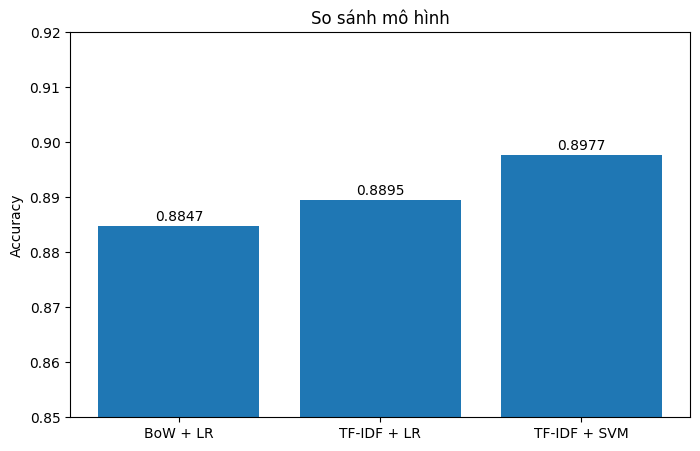

In [345]:
import matplotlib.pyplot as plt

models = ['BoW + LR', 'TF-IDF + LR', 'TF-IDF + SVM']
scores = [acc_bow, acc_tfidf, acc_svm]

plt.figure(figsize=(8,5))
bars = plt.bar(models, scores)


for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.001,
             f'{height:.4f}',
             ha='center')

plt.ylim(0.85, 0.92)
plt.ylabel("Accuracy")
plt.title("So sánh mô hình")
plt.show()

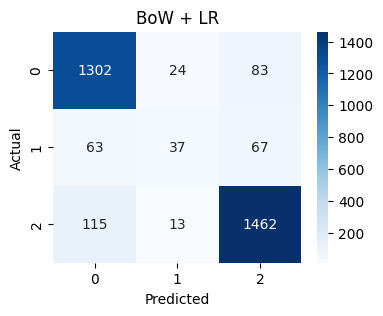

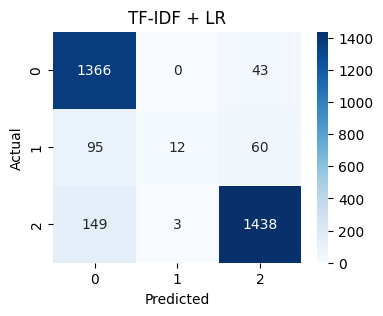

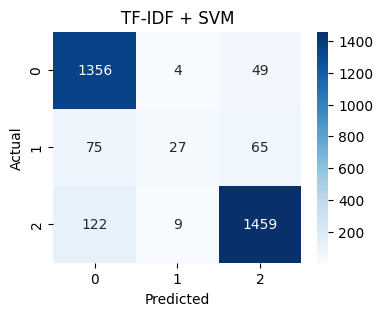

In [346]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_cm(Y_test, y_pred_bow, "BoW + LR")
plot_cm(Y_test, y_pred_tfidf, "TF-IDF + LR")
plot_cm(Y_test, y_pred_svm, "TF-IDF + SVM")

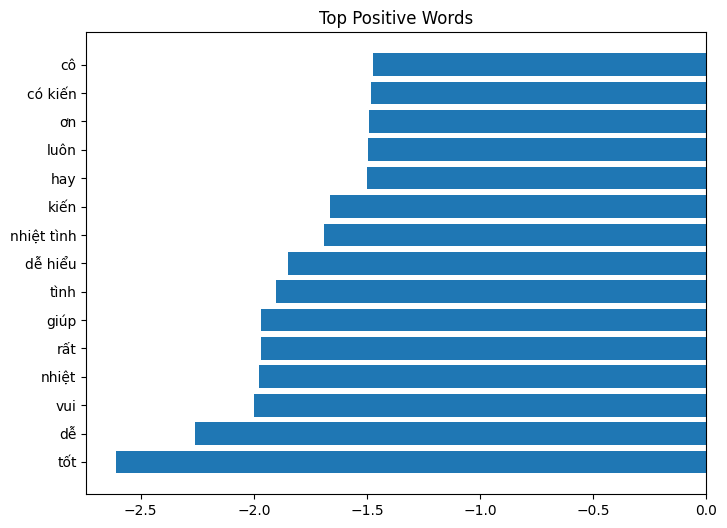

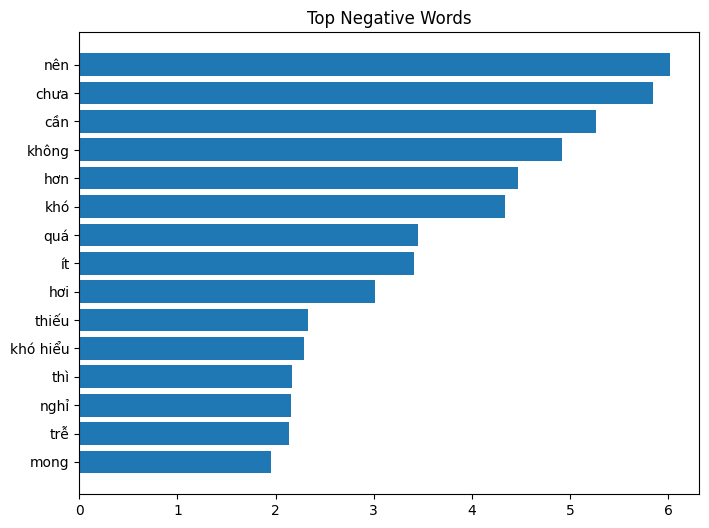

In [347]:
feature_names = tfidf_vectorizer.get_feature_names_out()
coef = model_tfidf.coef_[0]

top_negative_idx = coef.argsort()[-15:]
top_positive_idx = coef.argsort()[:15]

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_positive_idx], coef[top_positive_idx])
plt.title("Top Positive Words")
plt.show()

plt.figure(figsize=(8,6))
plt.barh(feature_names[top_negative_idx], coef[top_negative_idx])
plt.title("Top Negative Words")
plt.show()

# Homework

1. Try the following and **observe the accuracy changes**:

    - Change:
      ```python
      ngram_range=(1,3)

    *   Remove Vietnamese stopwords
    *   Experiment with:
      
        ```python
          max_features = 5000

In [348]:
# Sử dụng 1 danh sách các stopwords
with open(r"D:\NLP\tuan1\vietnamese-stopwords.txt", 'r', encoding='utf-8') as f:
    stopwords = list(set(f.read().splitlines()))

stopwords

['con_tính',
 'chung_ái',
 'chưa_kể',
 'ai_đó',
 'nhất_tề',
 'áng',
 'chốc_chốc',
 'không_phải',
 'để_lại',
 'nhằm_lúc',
 'đó_đây',
 'quá_trình',
 'vô_vàn',
 'xệp',
 'số_phần',
 'một_cơn',
 'đưa_tới',
 'nếu_cần',
 'bản_thân',
 'ăn_sáng',
 'ngay',
 'thực_vậy',
 'về_tay',
 'cuối_điểm',
 'những_ai',
 'chứ_sao',
 'mang_lại',
 'quá_thì',
 'những_muốn',
 'dễ_như_chơi',
 'sẽ_hay',
 'thường',
 'được',
 'xa_gần',
 'có_thế',
 'thậm_từ',
 'đáng_kể',
 'ư',
 'lượng_số',
 'trong_ấy',
 'tính_từ',
 'chọn_ra',
 'gặp',
 'cơ_cùng',
 'rày',
 'cũng_được',
 'qua_đi',
 'đáng_lí',
 'tông_tốc',
 'khá_tốt',
 'vào_vùng',
 'sẽ',
 'phía_trước',
 'phỏng',
 'thấp',
 'từ_điều',
 'trên_bộ',
 'sáng_thế',
 'bỏ_xa',
 'phải_như',
 'cây',
 'trả_của',
 'ý_hoặc',
 'chính_giữa',
 'không_có_gì',
 'xoẹt',
 'lại_ăn',
 'chắc_lòng',
 'sẽ_biết',
 'đánh_giá',
 'ở_được',
 'mang_nặng',
 'dưới_nước',
 'rõ',
 'thích_thuộc',
 'còn',
 'cả',
 'đại_nhân',
 'hơn_hết',
 'nhận_họ',
 'cho_tới',
 'bấy_chừ',
 'chứ_lại',
 'đủ_dùng',
 'người_khách'

In [349]:
# Chỉnh các thông số như đề bài:

tfidf_custom1 = TfidfVectorizer(
    ngram_range = (1, 3) 
)

tfidf_custom2 = TfidfVectorizer(
    max_features = 5000
)

tfidf_custom3 = TfidfVectorizer(
    stop_words = stopwords
)

In [350]:
# Chạy model LogisticRegression như bài mẫu với các thông sô thay đổi
X_train_custom1 = tfidf_custom1.fit_transform(X_train)
X_test_custom1 = tfidf_custom1.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_custom1, Y_train)

y_pred_custom1 = model.predict(X_test_custom1)
acc_custom1 = accuracy_score(Y_test, y_pred_custom1)

print("Accuracy TF-IDF sau khi chỉnh sửa ngram_range = (1, 3): ", acc_custom1)

svm_model = LinearSVC()
svm_model.fit(X_train_custom1, Y_train)

y_pred_svm1 = svm_model.predict(X_test_custom1)
acc_svm1 = accuracy_score(Y_test, y_pred_svm1)

print("Accuracy SVM + TF-IDF sau khi chỉnh sửa ngram_range = (1, 3):", acc_svm1)


Accuracy TF-IDF sau khi chỉnh sửa ngram_range = (1, 3):  0.8881869867340493
Accuracy SVM + TF-IDF sau khi chỉnh sửa ngram_range = (1, 3): 0.8948199620972836


In [351]:
# Chạy model LogisticRegression như bài mẫu với các thông sô thay đổi
X_train_custom2 = tfidf_custom2.fit_transform(X_train)
X_test_custom2 = tfidf_custom2.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_custom2, Y_train)

y_pred_custom2 = model.predict(X_test_custom2)
acc_custom2 = accuracy_score(Y_test, y_pred_custom2)

print("Accuracy TF-IDF sau khi chỉnh sửa max_features = 5000: ", acc_custom2)

svm_model = LinearSVC()
svm_model.fit(X_train_custom2, Y_train)

y_pred_svm2 = svm_model.predict(X_test_custom2)
acc_svm2 = accuracy_score(Y_test, y_pred_svm2)

print("Accuracy SVM + TF-IDF sau khi chỉnh sửa max_features = 5000:", acc_svm2)


Accuracy TF-IDF sau khi chỉnh sửa max_features = 5000:  0.8806064434617814
Accuracy SVM + TF-IDF sau khi chỉnh sửa max_features = 5000: 0.885028427037271


In [352]:
# Chạy model LogisticRegression như bài mẫu với các thông sô thay đổi
X_train_custom3 = tfidf_custom3.fit_transform(X_train)
X_test_custom3 = tfidf_custom3.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_custom3, Y_train)

y_pred_custom3 = model.predict(X_test_custom3)
acc_custom3 = accuracy_score(Y_test, y_pred_custom3)

print("Accuracy TF-IDF sau khi remove stopwords: ", acc_custom3)

svm_model = LinearSVC()
svm_model.fit(X_train_custom3, Y_train)

y_pred_svm3 = svm_model.predict(X_test_custom3)
acc_svm3 = accuracy_score(Y_test, y_pred_svm3)

print("Accuracy SVM + TF-IDF sau khi remove stopwords:", acc_svm3)


Accuracy TF-IDF sau khi remove stopwords:  0.7858496525584333
Accuracy SVM + TF-IDF sau khi remove stopwords: 0.7877447883765003


Accuracy sau khi chỉnh sửa ngram_range = (1, 3), remove VietNamese stopwords, max_features = 5000 thì giảm xuống còn 0.79 so với 0.88 của bài gốc

2. Try another model:
    *   Use Naive Bayes for sentiment classification.
    *   Error Analysis
        *   Print out 10 misclassified sentences
        *   Show the most important features (top weighted words)


In [353]:
#import thư viện để sử dụng model Naive Bayes
from sklearn.naive_bayes import MultinomialNB

#Sử dụng Naive Bayes
model_nb = MultinomialNB()
model_nb.fit(X_train_tfidf, Y_train)

y_pred_nb = model_nb.predict(X_test_tfidf)
acc_nb = accuracy_score(Y_test, y_pred_nb)

print("Accuracy Naive Bayes:", acc_nb)

Accuracy Naive Bayes: 0.8572331017056223


In [354]:
#In ra 10 câu lỗi, trong đó Sentence là câu, Actual là giá trị thực tế, Predicted là giá trị dự đoán

#Tạo 1 dataFrame với các thành phần Sentnce, Actual, Predicted ứng với X_test, Y_test và y_pred_nb
results = pd.DataFrame({'Sentence': X_test, 'Actual': Y_test, 'Predicted': y_pred_nb})

#Tạo 1 dataframe missclassified khi Actual khác Predicted và in ra 10 đòng đầu
misclassified = results[results['Actual'] != results['Predicted']]
print(misclassified.head(10))

                                             Sentence  Actual  Predicted
0                            nói tiếng anh lưu loát .       2          0
4   giáo viên không giảng dạy kiến thức , hướng dẫ...       0          2
6                        tính điểm thi đua các nhóm .       2          0
12  trong trường macbook thầy số hai thì không có ...       2          0
20                        bắt đầu buổi học đúng giờ .       2          0
27                cách mà cô tiếp cận với sinh viên .       1          2
31     phòng học thoáng mát , trang thiết bị đầy đủ .       2          0
33  không nhiệt tình chỉ dẫn và luôn gây khó khăn ...       0          2
35  môn học này giúp chúng em hiểu ra những vấn đề...       1          0
41                                               ổn .       1          0


In [355]:
#Gọi ra các features
feature_names = tfidf_vectorizer.get_feature_names_out()

#Với từng label, sort lại theo mức độ quan trọng và in ra feature quan trọng nhất
for i, label in enumerate(model_nb.classes_):
    top_features_indices = model_nb.feature_log_prob_[i].argsort()[::-1]
    top_word = feature_names[top_features_indices[0]]
    
    print(f"\nThe most important features for {label} is :", top_word)


The most important features for 0 is : không

The most important features for 1 is : không

The most important features for 2 is : tình


3. Advance task

    *   Implement TF–IDF from scratch (USING FORMULAR)
    *   Compute TF, IDF
    *   Multiply them using the mathematical formula
    *   Using: TfidfVectorizer(analyzer='char', ngram_range=(3,5))
    *   Apply to another dataset
    *   Train and evaluate the model on a different dataset.
    *   Write a comparison report





In [356]:
import math
import numpy as np
from collections import Counter, defaultdict

class CustomTFIDF:
    def __init__(self):
        # tạo 1 từ điển, 1 danh sách từ, và điểm idf
        self.vocabulary = []
        self.word_to_idx = {}
        self.idf_scores = {}
        
    def fit_transform(self, documents):
        N = len(documents)
        df = defaultdict(int)
        vocab_set = set()

        # Quét để tìm Vocab và đếm số lượng document chứa từ (DF)
        for doc in documents:
            if isinstance(doc, str) and len(doc.strip()) > 0:
                unique_words = set(doc.split())
                for word in unique_words:
                    df[word] += 1
                    vocab_set.add(word)

        self.vocabulary = sorted(list(vocab_set))
        self.word_to_idx = {word: i for i, word in enumerate(self.vocabulary)}

        # Tính IDF bằng công thức
        for word in self.vocabulary:
            self.idf_scores[word] = math.log(N / df[word]) + 1.0

        # Tạo ma trận TF-IDF
        tfidf_matrix = np.zeros((N, len(self.vocabulary)), dtype=np.float32)

        for i, doc in enumerate(documents):
            if not isinstance(doc, str) or len(doc.strip()) == 0:
                continue

            words = doc.split()
            doc_len = len(words)
            word_counts = Counter(words)

            for word, count in word_counts.items():
                if word in self.word_to_idx:
                    tf = count / doc_len
                    # Nhân TF với IDF
                    tfidf_matrix[i, self.word_to_idx[word]] = tf * self.idf_scores[word]

        return tfidf_matrix

    def transform(self, new_documents):
        N = len(new_documents)
        tfidf_matrix = np.zeros((N, len(self.vocabulary)), dtype=np.float32)

        for i, doc in enumerate(new_documents):
            if not isinstance(doc, str) or len(doc.strip()) == 0:
                continue

            words = doc.split()
            doc_len = len(words)
            word_counts = Counter(words)

            for word, count in word_counts.items():
                if word in self.word_to_idx:
                    tf = count / doc_len
                    tfidf_matrix[i, self.word_to_idx[word]] = tf * self.idf_scores[word]

        return tfidf_matrix

In [357]:
# Gọi class
custom_tfidf_model = CustomTFIDF()

# Lấy dữ liệu từ cột 'tokenized' của bạn chuyển thành list
train_documents = df['tokenized'].tolist() 

tfidf_matrix_train = custom_tfidf_model.fit_transform(train_documents)

In [362]:
#So sánh hàm tự code với hàm có sẵn:

documents = df['tokenized']
#Chỉnh sửa làm sklearn để phù hợp với hàm tự code
sklearn_vectorizer = TfidfVectorizer(
    token_pattern=r"(?u)\b\w+\b",   #Bắt cả từ có 1 ký tự giống hệt hàm .split()
    norm = None,                    #Tắt chuẩn hóa L2
    smooth_idf = False              #Không +1 vào tử/mẫu
)

# Chạy hàm Sklearn trên tập documents
sklearn_matrix_sparse = sklearn_vectorizer.fit_transform(documents)
sklearn_tfidf = sklearn_matrix_sparse.toarray()


#So sánh kích thước (Shape)
print("SO SÁNH KÍCH THƯỚC MA TRẬN")
print(tfidf_matrix_train.shape)
print(sklearn_tfidf.shape)

# So sánh điểm IF-IDF trên câu đầu tiên
print("Câu : ", documents[0])

for word in set(documents[0].split()):
    if word in custom_tfidf_model.word_to_idx and word in sklearn_vectorizer.vocabulary_:
        #Lấy điểm hàm tự code
        idx = custom_tfidf_model.word_to_idx[word]
        val = tfidf_matrix_train[0, idx]

        #Lấy điểm hàm tự Sklearn
        idx_sklearn = sklearn_vectorizer.vocabulary_[word]
        val_sklearn = sklearn_tfidf[0, idx_sklearn]
        
        print(f"Từ '{word}':")
        print(f"  + Tự code : {val}")
        print(f"  + Sklearn : {val_sklearn}")

SO SÁNH KÍCH THƯỚC MA TRẬN
(11426, 3810)
(11426, 3810)
Câu :  slide giáo_trình đầy_đủ
Từ 'giáo_trình':
  + Tự code : 1.9669984579086304
  + Sklearn : 5.900995482794092
Từ 'slide':
  + Tự code : 1.6060645580291748
  + Sklearn : 4.818193800152624
Từ 'đầy_đủ':
  + Tự code : 1.6087312698364258
  + Sklearn : 4.8261938428197


=> Nhận xét: Kích thước ma trận của hàm tự code và hàm có sẵn bằng nhau, giá trị của hàm có sẵn gấp 3 lần hàm tự code vì ở hàm tự code ta lấy tf[word] = count / len(words). Nếu ta không chia cho len(words) thì kết quả sẽ bằng nhau

In [363]:
#Load 1 dataset khác
ds = pd.read_csv(r"D:\NLP\tuan1\data.csv")
ds

,content,label,star
0,Áo bao đẹp ạ!,POS,5
1,Tuyệt vời,POS,5
2,2day ao khong giong trong,NEG,1
3,"Mùi thơm,bôi lên da mềm da",POS,5
4,"Vải đẹp, dày dặn",POS,5
...,...,...,...
31455,Không đáng tiền,NEG,1
31456,Quần rất đẹp,POS,5
31457,Hàng đẹp đúng giá tiền,POS,5
31458,Chất vải khá ổn,POS,4


In [364]:
#Gán tập X_new và Y_new là câu và label
X_new = ds['content']
y_new = ds['label']

#Chia test train/test
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_new, 
    y_new, 
    test_size=0.2, 
    random_state=42
)
X_train_new = X_train_new.fillna('')
X_test_new = X_test_new.fillna('')

In [365]:
#Chỉnh TfidfVectorizer(analyzer='char', ngram_range=(3, 5)) như đề bài
tfidf_new = TfidfVectorizer(analyzer='char', ngram_range=(3, 5))

X_train_char = tfidf_new.fit_transform(X_train_new) 
X_test_char = tfidf_new.transform(X_test_new)

model_new = LogisticRegression(max_iter=1000)
model_new.fit(X_train_char, y_train_new)

y_pred_new = model_new.predict(X_test_char)
acc_new = accuracy_score(y_test_new, y_pred_new)

print("Accuracy với Char-level TF-IDF:", acc_new)

Accuracy với Char-level TF-IDF: 0.7868722186904005


In [367]:
ds['clean_text'] = ds['content'].fillna("").astype(str).apply(clean_text)
ds['tokenized'] = ds['clean_text'].apply(tokenize_vi)

In [370]:
# Gọi class
custom_tfidf_model = CustomTFIDF()

# Lấy dữ liệu từ cột 'tokenized' của bạn chuyển thành list
train_documents = ds['tokenized'].tolist() 

tfidf_matrix_train = custom_tfidf_model.fit_transform(train_documents)

In [372]:
X = tfidf_matrix_train
y = ds['label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy với TF-IDF tự code:", accuracy)

Accuracy với TF-IDF tự code: 0.7693897012078831


=> Vậy Accuracy với TF-IDF tự code là 0.7694\
Accuracy với char-level TF-IDF là 0.7869 cao hơn

4. Rebuild the Naive Bayes Model Using Advanced Techniques
    * Combine N-gram Features with TF–IDF: Use both **unigram + bigram** to capture more context
    * Cross-validation: Instead of using a single train/test split, use k-fold cross-validation
    * Hyperparameter Tuning with GridSearchCV: search for the best parameter combination automatically.


In [377]:
from sklearn.model_selection import GridSearchCV

# Kết hợp sử dụng unigram và bigram
tfidf_4 = TfidfVectorizer(ngram_range=(1, 2))

X_train_4 = tfidf_4.fit_transform(X_train_new)
X_test_4 = tfidf_4.transform(X_test_new)

nb_model = MultinomialNB()

#Thử các giá trị alpha = 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0 để tìm ra alpha tốt nhất
# Chia thành k phần bằng nhau (ở đây là 5) (Phương pháp cross-calidation)
grid_search = GridSearchCV(
    estimator=nb_model, 
    param_grid= {'alpha': [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]}, 
    cv=5, 
    scoring='accuracy', 
    n_jobs=-1)

grid_search.fit(X_train_4, y_train_new)
#Chọn ra kết quả tốt nhất
best = grid_search.best_params_

print("Best param:", best)

y_pred_adv = grid_search.predict(X_test_4)
acc_4 = accuracy_score(y_test_new, y_pred_adv)

print("Accuracy : ", acc_4)

Best param: {'alpha': 0.5}
Accuracy :  0.7498410680228862


In [378]:
#Naive Bayes cơ bản
model_nb = MultinomialNB()
model_nb.fit(X_train_4, y_train_new)

y_pred_nb = model_nb.predict(X_test_4)
acc_nb = accuracy_score(y_test_new, y_pred_nb)

print("Accuracy Naive Bayes:", acc_nb)

Accuracy Naive Bayes: 0.7248887476160203


Kĩ thuật kết hợp Cross-validation và Hyperparameter Tuning with GridSearchCV cho ra accuracy tốt hơn so với cơ bản